# ***Introduction***
> ### ***About the Data:***
> This dataset contains transaction records from a coffee shop, covering the period from March 1, 2024, to March 23, 2025, during working hours (06:00–22:00).
> 
>The transactions are detailed by the following attributes:
>
>>- hour_of_day – the hour when the transaction occurred
>
>>- cash_type – payment method (e.g., cash, card)
>
>>- money – transaction amount
>
>>- coffee_name – type of beverage purchased
>
>>- Time_of_Day – time category (Morning, Afternoon, Evening, etc.)
>
>>- Weekday – day of the week (e.g., Mon, Tue, ...)
>
>>- Month_name – month of the transaction
>
>>- Weekdaysort – numerical order of the weekday
>
>>- Monthsort – numerical order of the month
>
>>- Date – transaction date
>
>>- Time – exact transaction time
>
>### ***Main goal of the notebook:***
>In this notebook, we will explore the coffee shop dataset and create several visualizations to better understand the transactions.

> ***importing librairies:*** 

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/coffe-sale/Coffe_sales.csv
/kaggle/input/coffee-store-sales/Coffee Shop Sales.pdf
/kaggle/input/coffee-store-sales/Coffe_sales.xlsx
/kaggle/input/coffee-store-sales/Coffee Shop Sales.pbix
/kaggle/input/coffee-sales-dataset/Coffe_sales.csv


>***loading the dataset:***

In [2]:
df = pd.read_csv('/kaggle/input/coffee-sales-dataset/Coffe_sales.csv')

df.shape 

(3547, 11)

>***checking the dataset:***

In [3]:
df.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   hour_of_day  3547 non-null   int64  
 1   cash_type    3547 non-null   object 
 2   money        3547 non-null   float64
 3   coffee_name  3547 non-null   object 
 4   Time_of_Day  3547 non-null   object 
 5   Weekday      3547 non-null   object 
 6   Month_name   3547 non-null   object 
 7   Weekdaysort  3547 non-null   int64  
 8   Monthsort    3547 non-null   int64  
 9   Date         3547 non-null   object 
 10  Time         3547 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 304.9+ KB


***
># ***Visualizations***


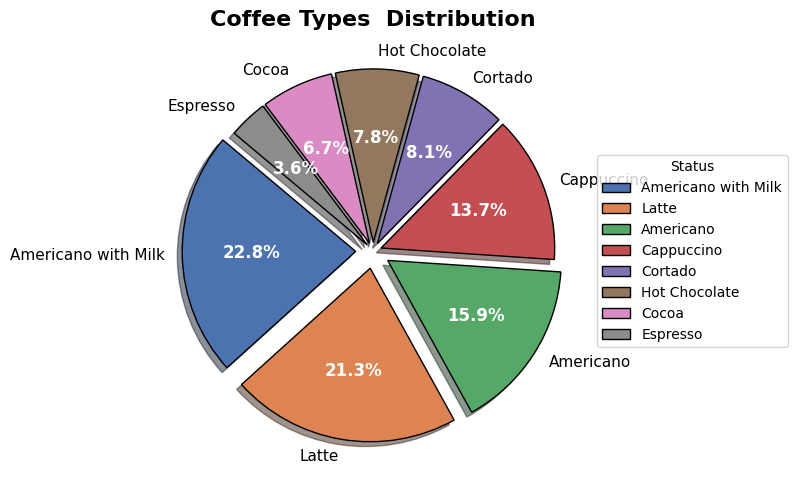

In [5]:
###Count occurrences of each coffee name
counts= df['coffee_name'].value_counts()
total= counts.sum()

###explosion to highlight important segments
explode = [0.1 if (v / total) >= 0.15 else 0.05 for v in counts.values]

###Plot
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    colors = sns.color_palette("deep") ,
    shadow=True,
    wedgeprops={'edgecolor': 'black'}
)

###Style tweaks
for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

###Title
ax.set_title("Coffee Types  Distribution", fontsize=16, fontweight='bold')

###Legend
ax.legend(wedges, counts.index, title="Status", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

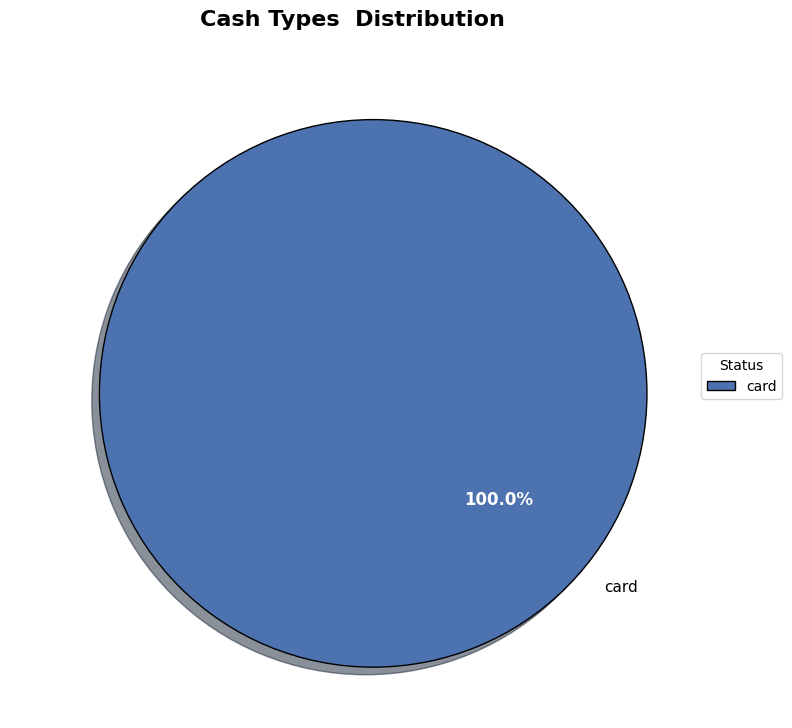

In [6]:
###Count occurrences of each cash type
counts = df['cash_type'].value_counts()


total = counts.sum()

###explosion to highlight important segments
explode = [0.1 if (v / total) >= 0.15 else 0.05 for v in counts.values]

###Plot
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    colors = sns.color_palette("deep") ,
    shadow=True,
    wedgeprops={'edgecolor': 'black'}
)

###Style tweaks
for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

###Title
ax.set_title("Cash Types  Distribution", fontsize=16, fontweight='bold')

###Legend
ax.legend(wedges, counts.index, title="Status", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()

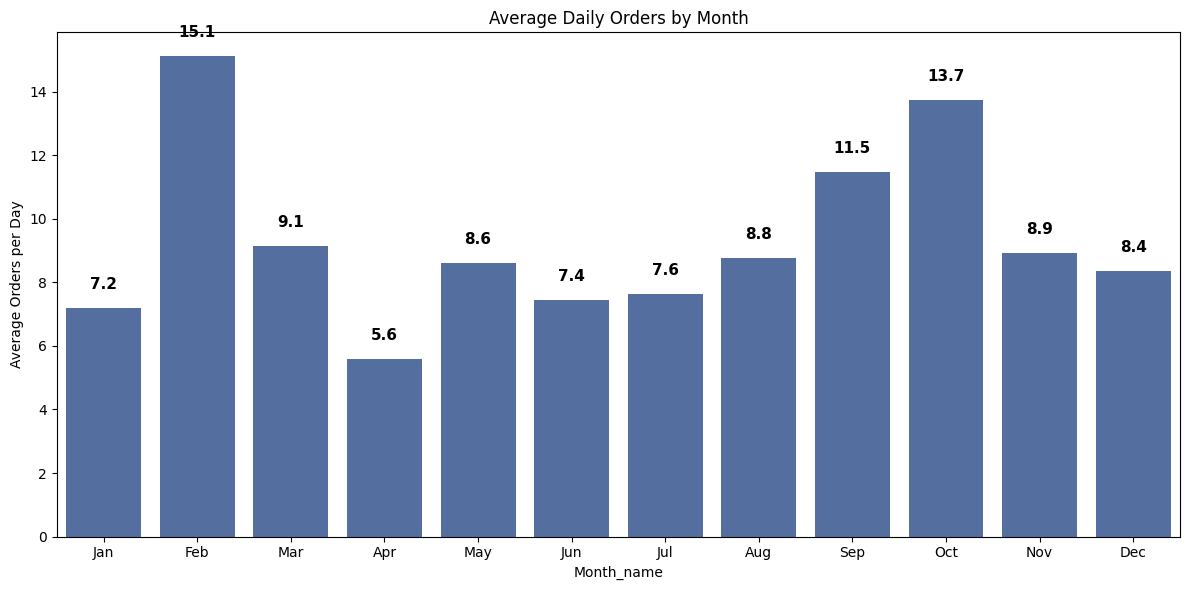

In [7]:
###calculate mean orders per months for each month:
monthly_counts= df.groupby(['Date', 'Month_name']).size().reset_index(name='count')
mean_per_month= monthly_counts.groupby('Month_name')['count'].mean().reset_index()

months_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul","Aug","Sep","Oct","Nov","Dec"]
###the plot cration:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=mean_per_month, x='Month_name', y='count',order= months_order, color="#486aad")
plt.ylabel('Average Orders per Day')
plt.title("Average Daily Orders by Month")

###Add value labels on bars:
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

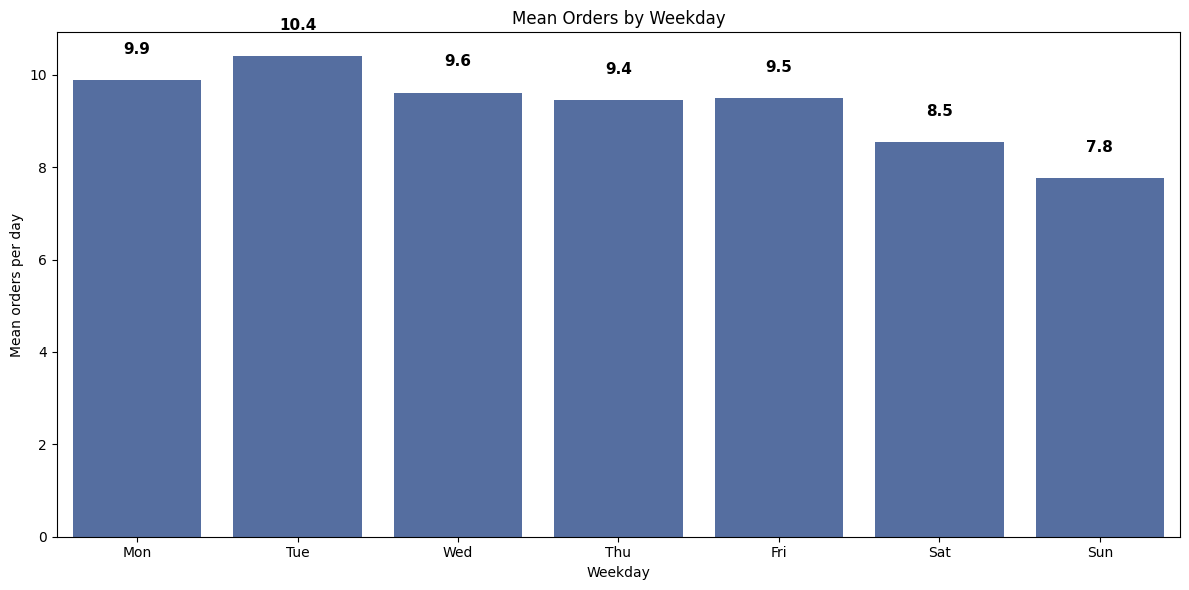

In [8]:
###calculate mean orders per day for each weekday:
daily_counts = df.groupby(['Date', 'Weekday']).size().reset_index(name='count')
mean_per_weekday = daily_counts.groupby('Weekday')['count'].mean().reset_index()

days_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
###plot creation:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=mean_per_weekday, x='Weekday', y='count', order= days_order, color="#486aad")
plt.ylabel('Mean orders per day')
plt.title("Mean Orders by Weekday")

###Add value labels on bars:
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Mean Order Distribution by Time of Day')

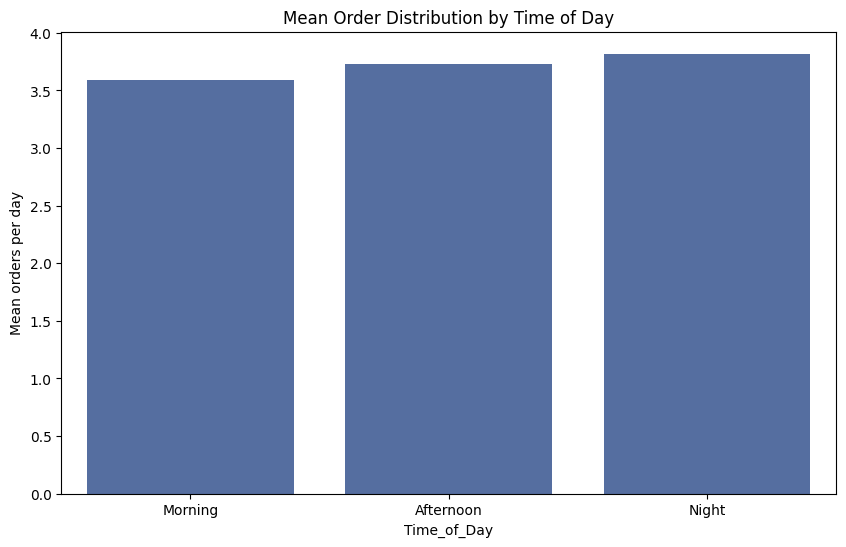

In [9]:
###Calculate mean orders per day for each part of Day:
daily_counts = df.groupby(['Date', 'Time_of_Day']).size().reset_index(name='count')
mean_per_day = daily_counts.groupby('Time_of_Day')['count'].mean().reset_index()

time_order= ['Morning','Afternoon','Night']
###plot:
plt.figure(figsize=(10, 6))
sns.barplot(data=mean_per_day, x='Time_of_Day', y='count',order= time_order, color="#486aad")
plt.ylabel('Mean orders per day')
plt.title("Mean Order Distribution by Time of Day")

<Figure size 1200x800 with 0 Axes>

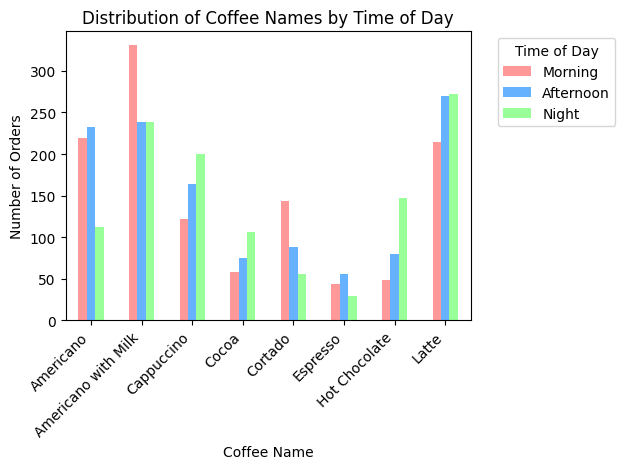

In [10]:
###crosstab to get counts:
coffee_time_dist= pd.crosstab(df['coffee_name'], df['Time_of_Day'])

coffee_time_dist = coffee_time_dist[time_order]

###bar chart:
plt.figure(figsize=(12, 8))
coffee_time_dist.plot(kind='bar', color=['#FF9999', '#66B2FF', '#99FF99', '#FFD700'])
plt.title('Distribution of Coffee Names by Time of Day')
plt.xlabel('Coffee Name')
plt.ylabel('Number of Orders')
plt.legend(title='Time of Day', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

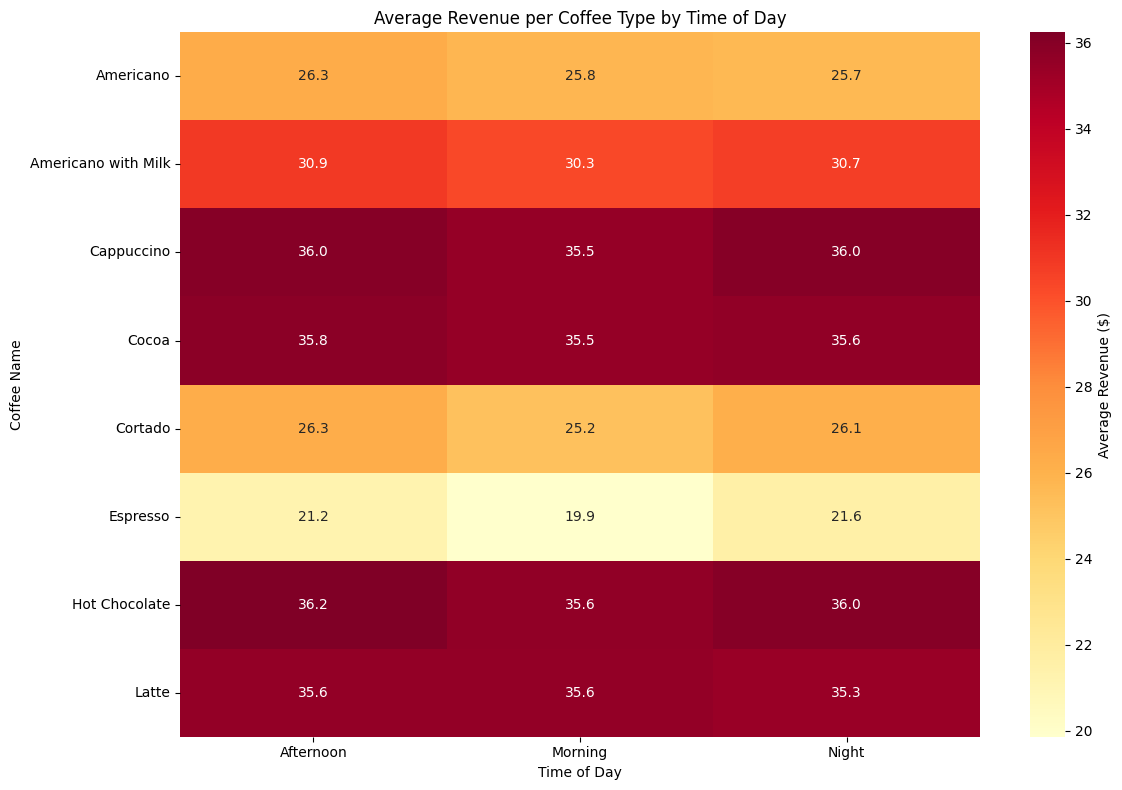

In [11]:
###average money spent per coffee type by time of day:
coffee_time_revenue = df.groupby(['coffee_name', 'Time_of_Day'])['money'].mean().unstack(fill_value=0)

###heatmap creation:
plt.figure(figsize=(12, 8))
sns.heatmap(coffee_time_revenue, 
            annot=True, 
            fmt='.1f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Average Revenue ($)'})
plt.title('Average Revenue per Coffee Type by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Coffee Name')
plt.tight_layout()
plt.show()

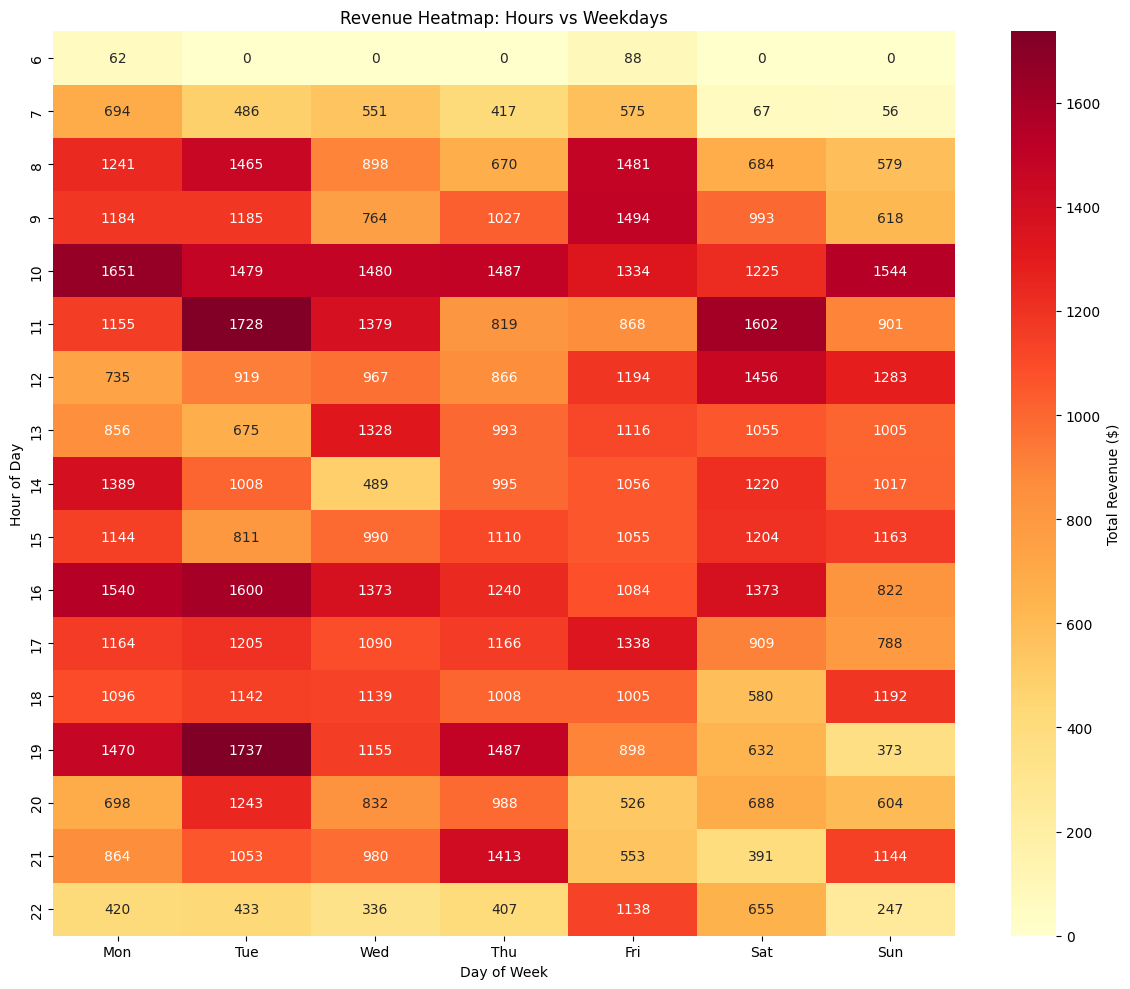

In [12]:
###total revenue by hour and weekday:
hour_day_revenue = df.groupby(['hour_of_day', 'Weekday'])['money'].sum().unstack(fill_value=0)



available_days = [day for day in days_order if day in hour_day_revenue.columns]
if available_days:
    hour_day_revenue = hour_day_revenue[available_days]

plt.figure(figsize=(12, 10))
sns.heatmap(hour_day_revenue, 
            annot=True, 
            fmt='.0f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Total Revenue ($)'})
plt.title('Revenue Heatmap: Hours vs Weekdays')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()


# 🌹 Thanks for checking out my notebook!
> ***I hope you found it useful. Feel free to share your thoughts in the comments.***